In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
df = pd.read_csv('data/process/loan_data_cleaned.csv')
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets_value,loan_to_income_ratio,assets_to_loan_ratio,income_per_dependent,loan_per_term
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,50700000,3.114583,1.695652,3.200000e+06,2.491667e+06
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,17000000,2.975610,1.393443,4.100000e+06,1.525000e+06
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,57700000,3.263736,1.942761,2.275000e+06,1.485000e+06
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,52700000,3.743902,1.716612,2.050000e+06,3.837500e+06
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,55000000,2.469388,2.272727,1.633333e+06,1.210000e+06
5,6,0,1,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,33900000,2.812500,2.511111,4.800000e+06,1.350000e+06
6,7,5,1,0,8700000,33000000,4,678,22500000,14800000,29200000,4300000,1,70800000,3.793103,2.145455,1.450000e+06,8.250000e+06
7,8,2,1,1,5700000,15000000,20,382,13200000,5700000,11800000,6000000,0,36700000,2.631579,2.446667,1.900000e+06,7.500000e+05
8,9,0,1,1,800000,2200000,20,782,1300000,800000,2800000,600000,1,5500000,2.750000,2.500000,8.000000e+05,1.100000e+05
9,10,5,0,0,1100000,4300000,10,388,3200000,1400000,3300000,1600000,0,9500000,3.909091,2.209302,1.833333e+05,4.300000e+05


# **1. Trình độ học vấn có ảnh hưởng đến số tiền vay hay không?**

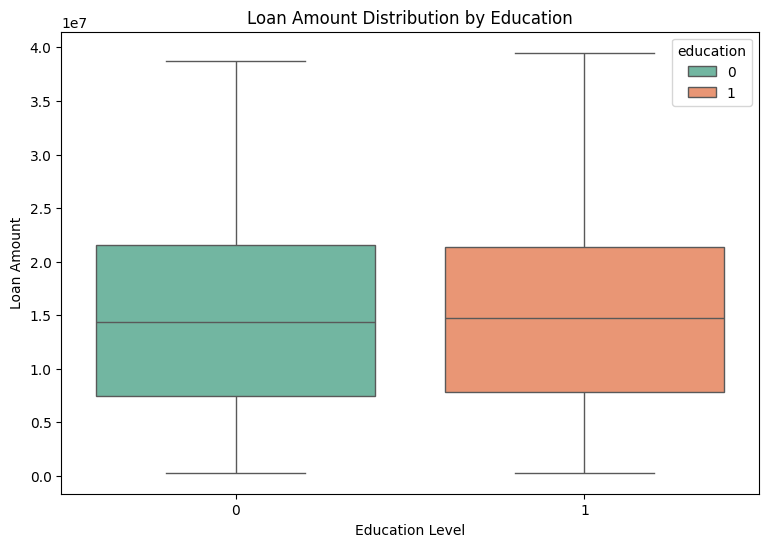

In [3]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=df,
    x='education', y='loan_amount', palette='Set2', hue='education'
)

plt.title('Loan Amount Distribution by Education')
plt.xlabel('Education Level')
plt.ylabel('Loan Amount')

plt.show()

In [4]:
import statsmodels.formula.api as smf
import statsmodels.stats.multicomp as multi

In [ ]:
model1 = smf.ols(formula=' ~ C(loan_status)', data=df)

In [15]:
result1 = model1.fit()

In [16]:
print(result1.summary())

                            OLS Regression Results                            
Dep. Variable:            loan_amount   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.113
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.291
Time:                        13:12:48   Log-Likelihood:                -74435.
No. Observations:                4269   AIC:                         1.489e+05
Df Residuals:                    4267   BIC:                         1.489e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.495e+07   2

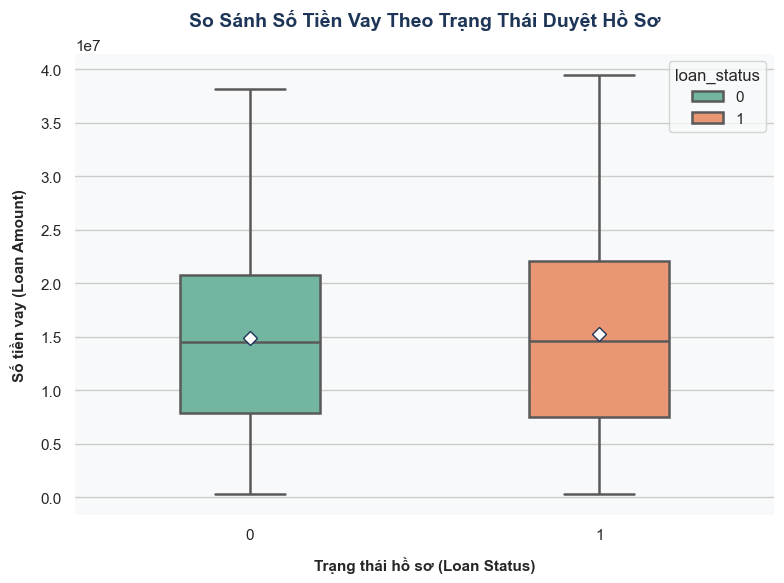

In [21]:
# 1. Khởi tạo cấu hình giao diện hiện đại
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#f8f9fa", "figure.facecolor": "white"})
plt.figure(figsize=(8, 6))  # Thu nhỏ chiều ngang một chút vì chỉ có 2 cột nhóm

# 2. Vẽ Boxplot theo biến loan_status
ax = sns.boxplot(
    x='loan_status',        # Trục X: Biến phân loại (Approved / Rejected hoặc 1 / 0)
    y='loan_amount',
    hue='loan_status',# Trục Y: Biến liên tục (Số tiền vay)
    data=df, 
    palette='Set2',         # Phân biệt 2 nhóm bằng 2 màu sắc rõ ràng từ hệ Set2
    width=0.4,              # Độ rộng vừa phải cho biểu đồ 2 cột
    linewidth=1.8,
    showmeans=True,         # Hiển thị điểm trung bình (Mean) để đối chiếu với mô hình OLS
    meanprops={
        "marker": "D", 
        "markerfacecolor": "white", 
        "markeredgecolor": "#1d3557", 
        "markersize": "7"
    },
    flierprops={         
        "marker": "o", 
        "markerfacecolor": "gray", 
        "markeredgecolor": "gray",
        "alpha": 0.4,
        "markersize": "4"
    }
)

# 3. Đồng bộ hóa tiêu đề và nhãn trục chuẩn xác
plt.title("So Sánh Số Tiền Vay Theo Trạng Thái Duyệt Hồ Sơ", 
          fontsize=14, pad=20, fontweight='bold', color='#1d3557')
plt.xlabel("Trạng thái hồ sơ (Loan Status)", fontsize=11, labelpad=10, fontweight='bold')
plt.ylabel("Số tiền vay (Loan Amount)", fontsize=11, labelpad=10, fontweight='bold')

# Nếu dữ liệu gốc ở dạng số (1 và 0), bạn có thể mở block code dưới đây để đổi tên nhãn cho đẹp:
# plt.xticks([0, 1], ['Từ chối (0)', 'Duyệt (1)'], fontsize=10)

# 4. Loại bỏ đường viền thừa và căn chỉnh
sns.despine(left=True, bottom=True) 
plt.tight_layout()
plt.show()

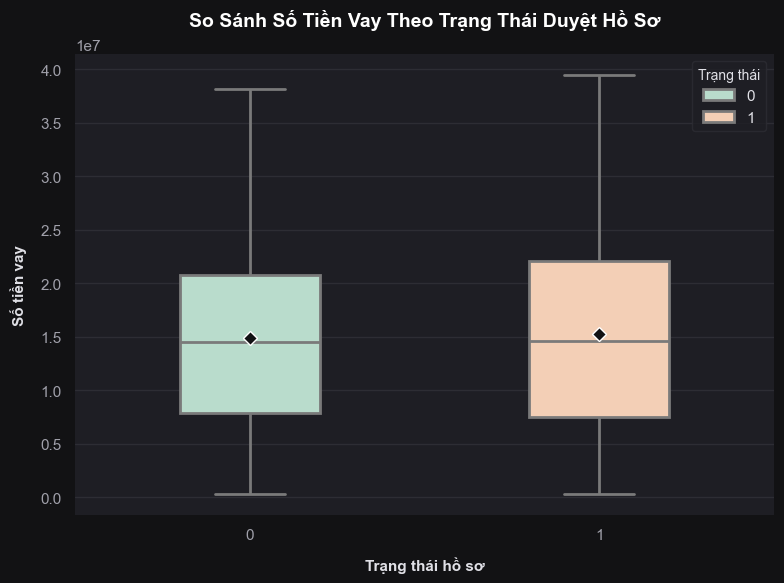

In [25]:


# 1. Thiết lập cấu hình Dark Mode chuyên nghiệp
# Sử dụng style "darkgrid" và cấu hình chi tiết màu nền, màu chữ thông qua rcParams
sns.set_theme(
    style="darkgrid", 
    rc={
        "axes.facecolor": "#1e1e24",     # Màu nền của vùng đồ thị (Xám than tối)
        "figure.facecolor": "#121214",   # Màu nền tổng thể phía ngoài
        "grid.color": "#2d2d34",         # Đường lưới tối, ẩn nhẹ để đỡ rối mắt
        "text.color": "#e0e0e6",         # Màu chữ chung (Trắng ngà, tránh dùng trắng tinh gây lóa)
        "axes.labelcolor": "#e0e0e6",    # Màu chữ của nhãn trục
        "xtick.color": "#a0a0aa",        # Màu chữ của giá trị trục X
        "ytick.color": "#a0a0aa"         # Màu chữ của giá trị trục Y
    }
)

plt.figure(figsize=(8, 6))

# 2. Vẽ Boxplot với bảng màu Neon/Pastel nổi bật trên nền tối
ax = sns.boxplot(
    x='loan_status',        
    y='loan_amount',
    hue='loan_status',      # Giữ nguyên cấu trúc của bạn
    data=df, 
    palette='Pastel2',      # Hệ màu Pastel giúp các hộp hiển thị cực kỳ sang và rõ trên nền tối
    width=0.4,              
    linewidth=2,            # Tăng nhẹ độ dày đường viền hộp để nổi bật hơn
    showmeans=True,         
    meanprops={
        "marker": "D", 
        "markerfacecolor": "#121214", # Đổi ruột dấu kim cương thành màu nền tối
        "markeredgecolor": "#ffffff", # Viền trắng tinh để làm nổi bật điểm Mean
        "markersize": "7"
    },
    flierprops={         
        "marker": "o", 
        "markerfacecolor": "#ff6b6b", # Điểm ngoại lai (Outliers) màu đỏ neon nhẹ để dễ nhận biết
        "markeredgecolor": "#ff6b6b",
        "alpha": 0.6,
        "markersize": "5"
    }
)

# 3. Đồng bộ hóa tiêu đề và nhãn trục (Tone màu sáng nổi bật)
plt.title("So Sánh Số Tiền Vay Theo Trạng Thái Duyệt Hồ Sơ", 
          fontsize=14, pad=20, fontweight='bold', color='#ffffff') # Tiêu đề trắng tinh
plt.xlabel("Trạng thái hồ sơ", fontsize=11, labelpad=10, fontweight='bold')
plt.ylabel("Số tiền vay", fontsize=11, labelpad=10, fontweight='bold')

# 4. Tối ưu hóa hiển thị chú thích (Legend) cho giao diện tối
plt.legend(
    title="Trạng thái", 
    title_fontsize='10', 
    loc='upper right', 
    frameon=True,
    facecolor='#1e1e24',     # Nền hộp chú thích trùng màu nền đồ thị
    edgecolor='#2d2d34',     # Viền hộp chú thích
    labelcolor='#e0e0e6'     # Màu chữ chú thích
)

# 5. Loại bỏ đường viền không cần thiết và hiển thị
sns.despine(left=True, bottom=True) 
plt.tight_layout()
plt.savefig('reports/images/anova/boxplot.png')
plt.show()